<a href="https://colab.research.google.com/github/BarryDeCicco/Dimensional_Reduction/blob/main/BERT_Test_Run.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

From an Google Search 'Word2Vec' (https://www.google.com/search?q=word2vec&sca_esv=e755c4fcff4cb9a6&rlz=1C1ONGR_enUS1065US1065&sxsrf=APpeQnse_RvzfuT5h5oe8j2BE1mcGgX8LA%3A1785529232767&ei=kANtatmzLrmXruEP-OKzgQk&biw=2874.6865234375&bih=1066.833740234375&sclient=gws-wiz-serp&fbs=ABfTbFVyMZGZf1hfvX9uKjN_-G8c4u0nXx4bEIpwm1lnNH832VstEKsVDqPorK0Gahnm2no1YAFtlsByIZaJlK7yr6gIShz8_nfnRyCFKBFanfbilXpMs-cznwqr4eRh15jLYnTY1jneHErIL1s8ylJ677g0-Yzv9SeiVzusgosrLmIdC_Li_URL_fqqHo09-SPTQ8fS7ou1p27xw7ju_YWEy8MXRBbSOQ&aep=10&ntc=1&mstk=AUtExfDjGCbGLkqwvITjmZJS3lyGsQh-otF9QlZqdVr5gU5RMD2IR2k1L8GgtstNNOkW8V58BHVtijYOvkBDi7NBM5A_oMG-Zf0baGofEpssl-8tXTTBHYJ-zAyQf1SsQaucVv5i4H8Y9dLE6rxIA0H8BWHQDetvUAovqUuPvmgMDxNYH-jXqmnl36Mo1P1SpuyQKJJ34T4c3k2XTIGzOnTpSBNSxkUATZYU0fZjdRK4CXHm30zQHWnNHqBKrc5SRmytvIXI2UnV4_CWRQ&aioh=3&csuir=1&cs=0&sourceid=chrome&ccb=1&hl=en-US&atvm=1&mtid=NgRtau_2NaPrmLQPuaTfsAg&udm=50)



#### Install Libraries

In [1]:
# Step 1: Install the Necessary Libraries

!pip install transformers datasets scikit-learn pandas


#### Load a Pre-trained Medical BERT Model:

In [2]:
# Step 2: Load a Pre-trained Medical BERT Model:

import torch
from transformers import AutoTokenizer, AutoModel

# Check that PyTorch sees your GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load the medical BERT tokenizer and model (BioBERT)
model_name = "dmis-lab/biobert-v1.1"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

print("✅ Medical BERT model successfully loaded onto your GPU!")


Using device: cpu


config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  433MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Medical BERT model successfully loaded onto your GPU!


#### Load/Create Datasets

In [3]:
# # Step 4: Create the Sample Dataset in Colab:

# import pandas as pd

# # Create a sample clinical dataset with a built-in anomaly
# data = {
#     'encounter_id': [101, 102, 103, 104, 105],
#     'specialty': ['Cardiology', 'Orthopedics', 'Pediatrics', 'Neurology', 'Gastroenterology'],
#     'clinical_notes': [
#         "Patient presents with intermittent chest pain and shortness of breath during exertion. EKG shows minor ST changes. Scheduled for a stress test.",
#         "A 45-year-old male with a closed fracture of the right radius following a fall. Closed reduction performed and fiberglass cast applied.",
#         "Routine 2-year well-child visit. Growth charts tracking at the 60th percentile. Immunizations updated. Normal developmental milestones met.",
#         "Patient complains of acute, severe crushing chest pain radiating to the left jaw, accompanied by diaphoresis and nausea. Emergency EKG ordered.", # ANOMALY: Cardiology text labeled as Neurology
#         "Subjective complaints of chronic abdominal bloating and epigastric burning after meals. Recommended upper endoscopy to rule out GERD or gastritis."
#     ]
# }

# df = pd.DataFrame(data)
# print(f"Dataset created successfully! Total records: {len(df)}")
# print(df[['encounter_id', 'specialty']])


In [4]:
# # Step 4b: Create a Larger Sample Dataset in Colab:

# import pandas as pd
# import numpy as np

# # Set random seed for reproducibility
# np.random.seed(42)

# # Templates for realistic clinical notes across 5 specialties
# templates = {
#     'Cardiology': [
#         "Patient complains of intermittent chest tightness and dyspnea on exertion. Scheduled for stress echo.",
#         "Follow-up for benign hypertension. Blood pressure controlled on Lisinopril. Regular EKG shows normal sinus rhythm.",
#         "A 62-year-old female presents with palpitations and fluttering sensations. Order 48-hour Holter monitor.",
#         "History of CAD and stenting. Current symptoms stable. Continue daily Aspirin and Atorvastatin regimen."
#     ],
#     'Orthopedics': [
#         "Patient presents with severe right knee pain following a twist during sports. Suspected meniscus tear, scheduled MRI.",
#         "Evaluation of chronic lower back pain radiating down the left leg. Positive straight leg raise test.",
#         "Follow-up for stable non-displaced fracture of the left fibula. X-ray shows good healing, transition to walking boot.",
#         "A 34-year-old male with persistent shoulder impingement. Administered local corticosteroid injection to subacromial bursa."
#     ],
#     'Pediatrics': [
#         "Routine 18-month well-child examination. Growth charts tracking well at 75th percentile. Vaccinations administered.",
#         "Mother reports 3-day history of low-grade fever, runny nose, and tugging at ears. Exam confirms acute otitis media.",
#         "Child presenting with acute dry barky cough and mild stridor. Diagnosed with mild croup, single dose of Decadron given.",
#         "School-age child presenting for sports physical. Normal cardiovascular, respiratory, and musculoskeletal exam."
#     ],
#     'Neurology': [
#         "Patient describes worsening chronic migraines occurring 3-4 times per week. Initiating Topamax for prophylaxis.",
#         "Evaluation of progressive resting tremor in right hand accompanied by bradykinesia. Consistent with early Parkinsonism.",
#         "A 55-year-old female presents with brief episodes of facial numbness and tingling. Schedule brain MRI with contrast.",
#         "Follow-up for well-controlled epilepsy. Patient reports being seizure-free for 12 months on Levetiracetam."
#     ],
#     'Gastroenterology': [
#         "Patient reports persistent epigastric burning and acid regurgitation worse at night. Prescribed Omeprazole.",
#         "Follow-up for moderate Crohn's disease. Patient reports clinical remission on current biologic therapy.",
#         "A 48-year-old male presenting with alternating constipation and diarrhea, accompanied by abdominal cramping.",
#         "Scheduled for screening colonoscopy due to strong family history of colon cancer. Preparation instructions provided."
#     ]
# }

# # Generate 97 normal records
# specialties_pool = list(templates.keys())
# generated_data = []

# # Generate sequential IDs starting at 101
# for i in range(97):
#     enc_id = 101 + i
#     # Ensure we don't accidentally claim our reserved anomaly IDs
#     if enc_id in [104, 135, 172]:
#         enc_id += 300

#     spec = np.random.choice(specialties_pool)
#     note = np.random.choice(templates[spec])

#     # Add minor random noise to text variations so they aren't identical copies
#     noise = f" Vital signs stable. Patient to follow up in {np.random.choice([2, 4, 6])} weeks."
#     generated_data.append({'encounter_id': enc_id, 'specialty': spec, 'clinical_notes': note + noise})

# # Form the initial DataFrame
# df = pd.DataFrame(generated_data)

# # Inject our 3 explicit anomalies with the exact target encounter IDs
# anomalies = [
#     {
#         'encounter_id': 104,
#         'specialty': 'Neurology',
#         'clinical_notes': "Patient complains of acute, severe crushing chest pain radiating to the left jaw, accompanied by diaphoresis and nausea. Emergency EKG ordered."
#     }, # ERROR: Clear Cardiology narrative mislabeled as Neurology
#     {
#         'encounter_id': 135,
#         'specialty': 'Pediatrics',
#         'clinical_notes': "A 78-year-old male presents with severe progressive resting tremor in the right hand and shuffling gait. Family notes memory decline."
#     }, # ERROR: Clear Geriatric Neurology narrative mislabeled as Pediatrics
#     {
#         'encounter_id': 172,
#         'specialty': 'Orthopedics',
#         'clinical_notes': "Subjective complaints of chronic abdominal bloating, sharp epigastric burning after meals, and dark tarry stools. Scheduled urgent upper endoscopy."
#     }  # ERROR: Clear Gastroenterology narrative mislabeled as Orthopedics
# ]

# # Append anomalies and reset the dataframe index
# df = pd.concat([df, pd.DataFrame(anomalies)], ignore_index=True)
# df = df.sort_values(by='encounter_id').reset_index(drop=True)

# print(f"📊 Dataset created successfully! Total records: {len(df)}")
# print("\nTarget Anomalies Hidden Inside the Dataset:")
# print(df[df['encounter_id'].isin([104, 135, 172])][['encounter_id', 'specialty']])

##### Try this with 1,000 realistic records from Hugging Face:

In [5]:
# # Step 1: Ingest and Scale the Base Dataset

# import pandas as pd
# from datasets import load_dataset

# print("🔄 Streaming real de-identified medical records from Hugging Face...")
# raw_dataset = load_dataset("NickyNicky/medical_mtsamples", split="train")
# all_records = pd.DataFrame(raw_dataset)

# # 1. Clean, strip, and standardize columns immediately
# all_records = all_records.rename(columns={'medical_specialty': 'specialty', 'transcription': 'clinical_notes'})
# all_records = all_records[['specialty', 'clinical_notes']].dropna()

# # Strip hidden trailing or leading whitespaces from both columns
# all_records['specialty'] = all_records['specialty'].str.strip()
# all_records['clinical_notes'] = all_records['clinical_notes'].str.strip()

# # 2. Broaden match criteria using case-insensitive partial string matches
# target_patterns = 'Cardiology|Orthopedics|Pediatrics|Neurology|Gastroenterology'
# filtered_df = all_records[all_records['specialty'].str.contains(target_patterns, case=False, na=False)].copy()

# # 3. Double-check population check to ensure data exists before sampling
# if len(filtered_df) == 0:
#     print("⚠️ Direct match failed. Using the full available dataset as a fallback.")
#     filtered_df = all_records.copy()

# # 4. Upsample safely to hit exactly 990 base records
# df_real = filtered_df.sample(n=990, replace=True, random_state=42).reset_index(drop=True)
# df_real['encounter_id'] = range(1001, 1001 + len(df_real))

# print(f"\n✅ Baseline successfully established! Compiled {len(df_real)} normal records.")
# print(df_real['specialty'].value_counts().head(5))


🔄 Streaming real de-identified medical records from Hugging Face...


mtsamples (1).csv: reconstructing file:   0%|          |  0.00B / 17.0MB            

mtsamples (1).csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/4999 [00:00<?, ? examples/s]


✅ Baseline successfully established! Compiled 990 normal records.
specialty
Neurology                440
Gastroenterology         407
Pediatrics - Neonatal    143
Name: count, dtype: int64


##### Inject the 10 Cross-Department Administrative Anomalies

In [6]:
# # Step 2: Inject the 10 Cross-Department Administrative Anomalies
# # Step 2: Inject the 10 Cross-Department Administrative Anomalies
# import pandas as pd

# # Systematically inject 10 structural mismatch errors across the departments
# anomalies_pool = [
#     {"encounter_id": 2001, "specialty": "Neurology", "clinical_notes": "Patient presents to emergency department with sudden crushing retrosternal chest pain radiating to left jaw, accompanied by profuse sweating and dyspnea. Initial EKG reveals acute ST-segment elevation. Prepared for immediate cardiac catheterization."},
#     {"encounter_id": 2002, "specialty": "Pediatrics", "clinical_notes": "An 84-year-old resident of an assisted living facility is evaluated for advanced cognitive decline, severe resting tremors in the right hand, and shuffling gait mechanics. Initiating trial of Carbidopa-Levodopa for Parkinsonian features."},
#     {"encounter_id": 2003, "specialty": "Orthopedics", "clinical_notes": "Chief complaint centers on burning epigastric pain radiating to the chest, significantly worse postprandially and when recumbent. Patient reports passing dark, tarry stools for two days. Urgently scheduling an upper endoscopy (EGD)."},
#     {"encounter_id": 2004, "specialty": "Cardiology", "clinical_notes": "A 4-year-old male child is brought in by his mother for a routine pediatric checkup and preschool clearance physical. Growth percentiles are tracking normally along the 70th line. Administered MMR and Varicella booster vaccines."},
#     {"encounter_id": 2005, "specialty": "Gastroenterology", "clinical_notes": "The patient is a 22-year-old varsity athlete who experienced an inversion injury to the right ankle during a basketball match. Marked localized edema and ecchymosis noted. Radiograph indicates an acute non-displaced distal fibula fracture."},
#     {"encounter_id": 2006, "specialty": "Neurology", "clinical_notes": "Patient presents with persistent watery diarrhea, severe lower abdominal cramping, and low-grade pyrexia following a recent course of Clindamycin. Stool assay is ordered to evaluate for Clostridioides difficile infection."},
#     {"encounter_id": 2007, "specialty": "Pediatrics", "clinical_notes": "A 67-year-old postmenopausal female presents with a bone mineral density T-score of -2.8 via DEXA scan, indicating severe systemic osteoporosis. Initiating monthly oral Bisphosphonate therapy and calcium supplementation."},
#     {"encounter_id": 2008, "specialty": "Cardiology", "clinical_notes": "Evaluation of a 45-year-old female complaining of a worsening throbbing unilateral headache accompanied by severe photophobia, phonophobia, and visual aura. Initiating prophylactic treatment with Topiramate."},
#     {"encounter_id": 2009, "specialty": "Gastroenterology", "clinical_notes": "Patient displays an acute onset of left-sided facial droop, slurred speech, and pronator drift of the left upper extremity. Transferred emergently to the neuro-ICU for acute ischemic stroke evaluation and potential tPA administration."},
#     {"encounter_id": 2010, "specialty": "Orthopedics", "clinical_notes": "Patient presents with progressive exertional dyspnea, orthopnea, and 3+ pitting edema of the lower extremities. Transthoracic echocardiogram demonstrates an ejection fraction reduced to 25%, consistent with congestive heart failure."}
# ]

# # Append anomalies to build your final 1,000-record set
# df = pd.concat([df_real, pd.DataFrame(anomalies_pool)], ignore_index=True)
# df = df.sort_values(by="encounter_id").reset_index(drop=True)

# print(f"📊 Global Production Dataset Finalized! Total records: {len(df)}")
# print(f"Hidden Anomaly Targets Inserted: {len(anomalies_pool)}")



📊 Global Production Dataset Finalized! Total records: 1000
Hidden Anomaly Targets Inserted: 10


#### **Use a non-duplicated set of 500 cells.**

In [20]:
import pandas as pd
from datasets import load_dataset

print("🔄 Streaming real unique medical records from Hugging Face...")
raw_dataset = load_dataset("NickyNicky/medical_mtsamples", split="train")
all_records = pd.DataFrame(raw_dataset)

# 1. Standardize columns and drop missing data
all_records = all_records.rename(columns={'medical_specialty': 'specialty', 'transcription': 'clinical_notes'})
all_records = all_records[['specialty', 'clinical_notes']].dropna()
all_records['specialty'] = all_records['specialty'].str.strip()
all_records['clinical_notes'] = all_records['clinical_notes'].str.strip()

# 2. Filter for our target specialties
target_patterns = 'Cardiology|Orthopedics|Pediatrics|Neurology|Gastroenterology'
filtered_df = all_records[all_records['specialty'].str.contains(target_patterns, case=False, na=False)].copy()

# 3. CRUCIAL CHANGE: Drop all duplicate text records entirely to prevent artificial bias
filtered_df = filtered_df.drop_duplicates(subset=['clinical_notes'])

# 4. Ingest ALL available unique records instead of duplicating to 990
df_real = filtered_df.copy().reset_index(drop=True)
df_real['encounter_id'] = range(1001, 1001 + len(df_real))

print(f"✅ Baseline established with {len(df_real)} completely UNIQUE medical records.")

# 5. Inject your 10 target anomalies
anomalies_pool = [
    {"encounter_id": 2001, "specialty": "Neurology", "clinical_notes": "Patient presents to emergency department with sudden crushing retrosternal chest pain radiating to left jaw, accompanied by profuse sweating and dyspnea. Initial EKG reveals acute ST-segment elevation. Prepared for immediate cardiac catheterization."},
    {"encounter_id": 2002, "specialty": "Pediatrics", "clinical_notes": "An 84-year-old resident of an assisted living facility is evaluated for advanced cognitive decline, severe resting tremors in the right hand, and shuffling gait mechanics. Initiating trial of Carbidopa-Levodopa for Parkinsonian features."},
    {"encounter_id": 2003, "specialty": "Orthopedics", "clinical_notes": "Chief complaint centers on burning epigastric pain radiating to the chest, significantly worse postprandially and when recumbent. Patient reports passing dark, tarry stools for two days. Urgently scheduling an upper endoscopy (EGD)."},
    {"encounter_id": 2004, "specialty": "Cardiology", "clinical_notes": "A 4-year-old male child is brought in by his mother for a routine pediatric checkup and preschool clearance physical. Growth percentiles are tracking normally along the 70th line. Administered MMR and Varicella booster vaccines."},
    {"encounter_id": 2005, "specialty": "Gastroenterology", "clinical_notes": "The patient is a 22-year-old varsity athlete who experienced an inversion injury to the right ankle during a basketball match. Marked localized edema and ecchymosis noted. Radiograph indicates an acute non-displaced distal fibula fracture."},
    {"encounter_id": 2006, "specialty": "Neurology", "clinical_notes": "Patient presents with persistent watery diarrhea, severe lower abdominal cramping, and low-grade pyrexia following a recent course of Clindamycin. Stool assay is ordered to evaluate for Clostridioides difficile infection."},
    {"encounter_id": 2007, "specialty": "Pediatrics", "clinical_notes": "A 67-year-old postmenopausal female presents with a bone mineral density T-score of -2.8 via DEXA scan, indicating severe systemic osteoporosis. Initiating monthly oral Bisphosphonate therapy and calcium supplementation."},
    {"encounter_id": 2008, "specialty": "Cardiology", "clinical_notes": "Evaluation of a 45-year-old female complaining of a worsening throbbing unilateral headache accompanied by severe photophobia, phonophobia, and visual aura. Initiating prophylactic treatment with Topiramate."},
    {"encounter_id": 2009, "specialty": "Gastroenterology", "clinical_notes": "Patient displays an acute onset of left-sided facial droop, slurred speech, and pronator drift of the left upper extremity. Transferred emergently to the neuro-ICU for acute ischemic stroke evaluation and potential tPA administration."},
    {"encounter_id": 2010, "specialty": "Orthopedics", "clinical_notes": "Patient presents with progressive exertional dyspnea, orthopnea, and 3+ pitting edema of the lower extremities. Transthoracic echocardiogram demonstrates an ejection fraction reduced to 25%, consistent with congestive heart failure."}
]

df = pd.concat([df_real, pd.DataFrame(anomalies_pool)], ignore_index=True)
df = df.sort_values(by="encounter_id").reset_index(drop=True)
print(f"📊 Global Dataset Finalized! Total records: {len(df)}")


🔄 Streaming real unique medical records from Hugging Face...
✅ Baseline established with 510 completely UNIQUE medical records.
📊 Global Dataset Finalized! Total records: 520


In [7]:
#### Process Text - this is for 1,000 records

In [21]:
import torch
import numpy as np
from tqdm.notebook import tqdm

# 1. Combine fields to provide full context
df['combined_text'] = "Specialty: " + df['specialty'] + " | Notes: " + df['clinical_notes']

# 2. Put the model in evaluation mode on the GPU
model.eval()

# Optimized batch extraction function
def get_bert_embeddings_batched(text_list, batch_size=16):
    all_embeddings = []

    # Process records in chunks (batches) to maximize GPU speed safely
    for i in tqdm(range(0, len(text_list), batch_size), desc="Processing Batches"):
        batch_texts = text_list[i:i+batch_size]

        # Tokenize the entire batch at once
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        ).to(device)

        # Extract features without calculating gradients (saves memory)
        with torch.no_grad():
            outputs = model(**inputs)

        # Pull vectors from GPU memory back to CPU as a NumPy matrix
        embeddings = outputs.pooler_output.cpu().numpy()
        all_embeddings.append(embeddings)

    return np.vstack(all_embeddings)

print("Starting BioBERT vector extraction on 1,000 records...")
# Run the batch process on our unified text column
X = get_bert_embeddings_batched(df['combined_text'].tolist(), batch_size=16)

# Save the individual vectors back into the dataframe for our downstream scripts
df['vector'] = list(X)
print(f"✅ Finished! Created vector matrix with shape: {X.shape}")


Starting BioBERT vector extraction on 1,000 records...


Processing Batches:   0%|          | 0/33 [00:00<?, ?it/s]

✅ Finished! Created vector matrix with shape: (520, 768)


##### Prevous Processing (100 records)

In [9]:
# import torch
# import numpy as np

# # Ensure your model from the previous step is active
# # model.eval() # This line should ideally be called once, outside the function or in an earlier setup cell

# def get_bert_embedding(text):
#     # Tokenize text and move tensors to the GPU
#     inputs = tokenizer(text, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)

#     with torch.no_grad():
#         outputs = model(**inputs)

#     # Extract the 'Pooler Output' which represents the semantic meaning of the entire text block
#     embeddings = outputs.pooler_output.cpu().numpy()
#     return embeddings[0]

# # Step 4.5  Create a unified text field for the model to read (inserted in later)

# df['combined_text'] = "Specialty: " + df['specialty'] + " | Notes: " + df['clinical_notes']

# # Function to get embeddings (using the function we defined in the previous step)
# print("Generating contextual embeddings for combined text...")
# embeddings_list = []
# for text in df['combined_text']:
#     # Get vector and squeeze to flatten from (1, 768) to (768,)
#     vector = get_bert_embedding(text).squeeze()
#     embeddings_list.append(vector)

# # Convert list to a clean 2D NumPy array for machine learning
# X = np.array(embeddings_list)
# print(f"Matrix shape: {X.shape} (5 records, 768 mathematical features each)")

In [22]:

print(X)
type(X)



[[ 0.10826062  0.01475572  0.96585345 ...  0.9723027  -0.0883072
   0.9998916 ]
 [ 0.09943374  0.07639499  0.98550105 ...  0.99173486 -0.0699528
   0.9999556 ]
 [ 0.05164264  0.15198302  0.9779758  ...  0.98715705 -0.01762713
   0.9999402 ]
 ...
 [-0.06017095  0.1509238   0.9941373  ...  0.9978092   0.05919085
   0.99999917]
 [-0.07837683  0.13876428  0.99691755 ...  0.9984179  -0.06571463
   0.9999989 ]
 [-0.00549524  0.08944732  0.99327886 ...  0.99747705 -0.05154875
   0.9999986 ]]


numpy.ndarray

# **On Tuesday morning, start here ('Paste and Run This in Your Step 7 Cell Once the Embedding Finishes:') - type "Resume at Step 7 cell"**

In [ ]:
#### Convert Text into Medical BERT Embeddings:

In [23]:
# Step 5: Convert Text into Medical BERT Embeddings:

import torch
import numpy as np

# Ensure your model from the previous step is active
model.eval()

def get_bert_embedding(text):
    # Tokenize text and move tensors to the GPU
    inputs = tokenizer(text, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    # Extract the 'Pooler Output' which represents the semantic meaning of the entire text block
    embeddings = outputs.pooler_output.cpu().numpy()
    return embeddings[0]

# Generate vectors for all clinical notes
print("Processing text through BioBERT on the GPU...")
df['vector'] = df['clinical_notes'].apply(get_bert_embedding)
print("✅ Text converted into dense math vectors successfully!")



Processing text through BioBERT on the GPU...
✅ Text converted into dense math vectors successfully!


#### Detect the Anomaly Using Isolation Forest:

In [24]:
# Step 6: Detect the Anomaly Using Isolation Forest:


from sklearn.ensemble import IsolationForest

# Initialize Isolation Forest
# contamination=0.20 tells the AI we expect roughly 20% of our data (1 out of 5) to be anomalous
# iso_forest = IsolationForest(contamination=0.20, random_state=42)

# Initialize the forest WITHOUT a hardcoded contamination percentage
iso_forest_raw = IsolationForest(contamination='auto', random_state=42)
iso_forest_raw.fit(X)

# Train the model on our BERT vectors and predict outliers
# Predictions return: 1 for normal data, -1 for anomalies
df['anomaly_score'] = iso_forest_raw.predict(X)

# Display the results
print("\n--- DETECTED ANOMALIES ---")
for index, row in df.iterrows():
    status = "⚠️ ANOMALY DETECTED" if row['anomaly_score'] == -1 else "✅ Normal Record"
    print(f"\nEncounter ID: {row['encounter_id']} | Status: {status}")
    print(f"Assigned Specialty: {row['specialty']}")
    print(f"Notes snippet: {row['clinical_notes'][:80]}...")

# Extract raw anomaly scores (lower/more negative = more anomalous)
# Note: sklearn offsets the score so that negative numbers are outliers
df['raw_anomaly_score'] = iso_forest_raw.score_samples(X)

# Sort records to show the most suspicious ones at the very top
df_sorted = df.sort_values(by='raw_anomaly_score')
print("\n--- SORTED RECORDS ---")
print(df_sorted[['encounter_id', 'specialty', 'raw_anomaly_score']])


--- DETECTED ANOMALIES ---

Encounter ID: 1001 | Status: ✅ Normal Record
Assigned Specialty: Neurology
Notes snippet: CC:, Confusion and slurred speech.,HX , (primarily obtained from boyfriend): Thi...

Encounter ID: 1002 | Status: ✅ Normal Record
Assigned Specialty: Pediatrics - Neonatal
Notes snippet: SUBJECTIVE:,  This is a 1-month-old who comes in for a healthy checkup.  Mom say...

Encounter ID: 1003 | Status: ✅ Normal Record
Assigned Specialty: Pediatrics - Neonatal
Notes snippet: SUBJECTIVE:,  Patient presents with Mom and Dad for her 5-year 3-month well-chil...

Encounter ID: 1004 | Status: ✅ Normal Record
Assigned Specialty: Pediatrics - Neonatal
Notes snippet: SUBJECTIVE:,  The patient presents with Mom and Dad for her 1-year well child ch...

Encounter ID: 1005 | Status: ✅ Normal Record
Assigned Specialty: Pediatrics - Neonatal
Notes snippet: SUBJECTIVE:,  The patient presents with Mom for a first visit to our office for ...

Encounter ID: 1006 | Status: ✅ Normal Record
Ass

**Dynamically Setting the Threshold. **Once you have thousands of records, you cannot look at them one by one. You use statistical rules of thumb to isolate the threshold programmatically:


*   The Standard Deviation Rule (Extreme Outliers): Calculate the average score of your dataset. Flag any record that sits more than 2 or 3 standard deviations away from that average.
*   The Percentile Method for Auditing Budgets: If your quality assurance department only has the manpower to review 50 records a week, you simply sort your database by the lowest raw_anomaly_score and pull the Top 50 worst scores, regardless of percentage.








In [25]:
# # Step 7: Try This Statistical Thresholding Script

# import numpy as np

# scores = df['raw_anomaly_score'].values
# mean_score = np.mean(scores)
# std_score = np.std(scores)

# # Define a statistical threshold (e.g., 1 standard deviation away for this tiny dataset)
# # For large datasets, 2 or 3 standard deviations is standard
# threshold = mean_score - (1.0 * std_score)

# df['dynamic_anomaly_flag'] = df['raw_anomaly_score'].apply(lambda x: "⚠️ ANOMALY" if x < threshold else "✅ Normal")

# print(f"Calculated Dataset Mean Score: {mean_score:.4f}")
# print(f"Statistical Anomaly Cutoff Threshold: {threshold:.4f}\n")
# print(df[['encounter_id', 'specialty', 'raw_anomaly_score', 'dynamic_anomaly_flag']])


#### Statistical Thresholding Script

In [26]:
# Step 7: Try This Statistical Thresholding Script (Optimized for 1,000 Records)
import numpy as np
import textwrap
from sklearn.ensemble import IsolationForest
from google.colab import data_table

# 1. Initialize and run the Isolation Forest on your new 1000x768 vector matrix
print("Training Isolation Forest on production vector matrix...")
iso_forest_prod = IsolationForest(contamination='auto', random_state=42)
iso_forest_prod.fit(X)

# Extract raw anomaly scores (lower = more anomalous)
df['raw_anomaly_score'] = iso_forest_prod.score_samples(X)

# 2. Calculate statistical metrics
scores = df['raw_anomaly_score'].values
mean_score = np.mean(scores)
std_score = np.std(scores)

# Use a strict 2.5 standard deviation cutoff for a 1% anomaly rate
threshold = mean_score - (2.5 * std_score)

# Apply flags to the dataframe
df['dynamic_anomaly_flag'] = df['raw_anomaly_score'].apply(lambda x: "⚠️ ANOMALY" if x < threshold else "✅ Normal")

# 3. Print high-level summary metrics
print("\n==================================================")
print(f"📊 SYSTEM METRICS SUMMARY")
print("==================================================")
print(f"Calculated Dataset Mean Score: {mean_score:.4f}")
print(f"Statistical Anomaly Cutoff Threshold: {threshold:.4f}")

# 4. Explicitly list all flagged cases first with 80-character line wrapping
print("==================================================")
print("⚠️ FLAGGED ANOMALY ENCOUNTERS (FOR HUMAN REVIEW)")
print("==================================================")
anomalies_only = df[df['dynamic_anomaly_flag'] == "⚠️ ANOMALY"].sort_values(by='raw_anomaly_score')

print(f"Total anomalies flagged: {len(anomalies_only)}\n")

if len(anomalies_only) > 0:
    for index, row in anomalies_only.iterrows():
        print(f"• ID: {row['encounter_id']} | Specialty: {row['specialty']} | Score: {row['raw_anomaly_score']:.4f}")

        # Wrap text to 80 characters and indent subsequent lines cleanly
        wrapped_notes = textwrap.fill(row['clinical_notes'], width=80, initial_indent="  Notes: ", subsequent_indent="         ")
        print(f"{wrapped_notes}\n")
        print("-" * 40)
else:
    print("No anomalies detected under the current statistical threshold.\n")

# 5. Enable and display the entire dataset in a scrollable format
print("\n==================================================")
print("📋 COMPLETE ENCOUNTER DATASET (SCROLLABLE TABLE)")
print("==================================================")

# Configure Colab's interactive table output settings
data_table.enable_dataframe_formatter()
display(df[['encounter_id', 'specialty', 'raw_anomaly_score', 'dynamic_anomaly_flag']])


Training Isolation Forest on production vector matrix...

📊 SYSTEM METRICS SUMMARY
Calculated Dataset Mean Score: -0.4151
Statistical Anomaly Cutoff Threshold: -0.5253
⚠️ FLAGGED ANOMALY ENCOUNTERS (FOR HUMAN REVIEW)
Total anomalies flagged: 14

• ID: 1316 | Specialty: Gastroenterology | Score: -0.7085
  Notes: HISTORY OF PRESENT ILLNESS: ,  The patient is a 48-year-old man who has
         had abdominal pain since October of last year associated with a
         30-pound weight loss and then developed jaundice.  He had epigastric
         pain and was admitted to the hospital.  A thin-slice CT scan was
         performed, which revealed a 4 x 3 x 2 cm pancreatic mass with involved
         lymph nodes and ring enhancing lesions consistent with liver
         metastases.  The patient, additionally, had a questionable pseudocyst
         in the tail of the pancreas.  The patient underwent ERCP on 04/04/2007
         with placement of a stent.  This revealed a strictured pancreatic duct,


,encounter_id,specialty,raw_anomaly_score,dynamic_anomaly_flag
0,1001,Neurology,-0.402610,✅ Normal
1,1002,Pediatrics - Neonatal,-0.389251,✅ Normal
2,1003,Pediatrics - Neonatal,-0.397927,✅ Normal
3,1004,Pediatrics - Neonatal,-0.378008,✅ Normal
4,1005,Pediatrics - Neonatal,-0.400541,✅ Normal
...,...,...,...,...
515,2006,Neurology,-0.479218,✅ Normal
516,2007,Pediatrics,-0.467149,✅ Normal
517,2008,Cardiology,-0.488164,✅ Normal
518,2009,Gastroenterology,-0.473571,✅ Normal


In [27]:
from google.colab import data_table
data_table.enable_dataframe_formatter()
df_anomalies = df[df['dynamic_anomaly_flag'] == "⚠️ ANOMALY"]
display(df_anomalies)

,specialty,clinical_notes,encounter_id,combined_text,vector,anomaly_score,raw_anomaly_score,dynamic_anomaly_flag
65,Pediatrics - Neonatal,"PROCEDURE:, Delayed primary chest closure.,IND...",1066,Specialty: Pediatrics - Neonatal | Notes: PROC...,"[-0.074606635, 0.08317152, 0.9091306, -0.99915...",-1,-0.563569,⚠️ ANOMALY
140,Neurology,"FINDINGS:,Normal foramen magnum.,Normal brains...",1141,"Specialty: Neurology | Notes: FINDINGS:,Normal...","[-0.03285449, 0.113974586, 0.98270345, -0.9995...",-1,-0.528064,⚠️ ANOMALY
155,Neurology,"FINDINGS:,There is a large intrasellar mass le...",1156,"Specialty: Neurology | Notes: FINDINGS:,There ...","[-0.09613607, -0.0069870986, 0.9701733, -0.999...",-1,-0.592110,⚠️ ANOMALY
179,Neurology,"CHIEF COMPLAINT:, Intractable epilepsy, here ...",1180,Specialty: Neurology | Notes: CHIEF COMPLAINT:...,"[0.016213138, 0.01042048, 0.91661346, -0.99957...",-1,-0.579139,⚠️ ANOMALY
184,Neurology,"CC:, Headache,HX: ,37 y/o RHF presented to her...",1185,"Specialty: Neurology | Notes: CC:, Headache,HX...","[0.07053271, 0.030983193, 0.862685, -0.9996024...",-1,-0.549122,⚠️ ANOMALY
190,Neurology,"PREOPERATIVE DIAGNOSIS:, Right occipital arte...",1191,Specialty: Neurology | Notes: PREOPERATIVE DIA...,"[0.004380427, -0.0005965996, 0.8643617, -0.998...",-1,-0.687868,⚠️ ANOMALY
263,Neurology,"PREOPERATIVE DIAGNOSIS: , Right chronic subdur...",1264,Specialty: Neurology | Notes: PREOPERATIVE DIA...,"[-0.02371001, 0.009701691, 0.9140687, -0.99920...",-1,-0.538462,⚠️ ANOMALY
315,Gastroenterology,"HISTORY OF PRESENT ILLNESS: , The patient is ...",1316,Specialty: Gastroenterology | Notes: HISTORY O...,"[0.09873316, -0.018162271, 0.65173495, -0.9988...",-1,-0.708495,⚠️ ANOMALY
331,Gastroenterology,"PREOPERATIVE DIAGNOSIS: , Biliary colic.",1332,Specialty: Gastroenterology | Notes: PREOPERAT...,"[0.052978896, 0.106568746, 0.91877997, -0.9999...",-1,-0.571930,⚠️ ANOMALY
335,Gastroenterology,"PREOPERATIVE DIAGNOSIS:, Cholelithiasis; poss...",1336,Specialty: Gastroenterology | Notes: PREOPERAT...,"[0.16271123, 0.0655076, 0.8887675, -0.99999756...",-1,-0.617220,⚠️ ANOMALY


In [17]:
anomaly_counts_by_specialty = df_anomalies['specialty'].value_counts()
display(anomaly_counts_by_specialty)

,count
specialty,
Gastroenterology,21
Neurology,12


In [ ]:
# # Step 7: Try This Statistical Thresholding Script (old, meant for 100 records)
# import numpy as np
# import textwrap
# from google.colab import data_table

# # 1. Calculate statistical metrics
# scores = df['raw_anomaly_score'].values
# mean_score = np.mean(scores)
# std_score = np.std(scores)

# # Define a statistical threshold (Using 2 standard deviations)
# threshold = mean_score - (2.0 * std_score)

# # Apply flags to the dataframe
# df['dynamic_anomaly_flag'] = df['raw_anomaly_score'].apply(lambda x: "⚠️ ANOMALY" if x < threshold else "✅ Normal")

# # 2. Print high-level summary metrics
# print("==================================================")
# print(f"📊 SYSTEM METRICS SUMMARY")
# print("==================================================")
# print(f"Calculated Dataset Mean Score: {mean_score:.4f}")
# print(f"Statistical Anomaly Cutoff Threshold: {threshold:.4f}\n")

# # 3. Explicitly list all flagged cases first with 80-character line wrapping
# print("==================================================")
# print("⚠️ FLAGGED ANOMALY ENCOUNTERS (FOR HUMAN REVIEW)")
# print("==================================================")
# anomalies_only = df[df['dynamic_anomaly_flag'] == "⚠️ ANOMALY"]

# if len(anomalies_only) > 0:
#     for index, row in anomalies_only.iterrows():
#         print(f"• ID: {row['encounter_id']} | Specialty: {row['specialty']} | Score: {row['raw_anomaly_score']:.4f}")

#         # Wrap text to 80 characters and indent subsequent lines for cleaner reading
#         wrapped_notes = textwrap.fill(row['clinical_notes'], width=80, initial_indent="  Notes: ", subsequent_indent="         ")
#         print(f"{wrapped_notes}\n")
# else:
#     print("No anomalies detected under the current statistical threshold.\n")

# # 4. Enable and display the entire dataset in a scrollable format
# print("==================================================")
# print("📋 COMPLETE ENCOUNTER DATASET (SCROLLABLE TABLE)")
# print("==================================================")

# # Configure Colab's interactive table output settings
# data_table.enable_dataframe_formatter()
# display(df[['encounter_id', 'specialty', 'raw_anomaly_score', 'dynamic_anomaly_flag']])


#### Flag records as Anomalous.

In [ ]:
# Step 8: This is a correction script, to suggest to which specialty a record should be assigned to
# in this case, for illustration, it uses the known value of the anomalous case (4), but could
# be modified to pull case record numbers whose values were based on thresholds.

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import textwrap

# Step 1: Isolate our known "good" clean records to build baseline profiles
# We dynamically exclude ANY record that our model flagged as an anomaly
clean_df = df[df['dynamic_anomaly_flag'] == "✅ Normal"]
anomalous_df = df[df['dynamic_anomaly_flag'] == "⚠️ ANOMALY"]

# Create a dictionary to store the baseline vector for each specialty
specialty_baselines = {}
for spec in clean_df['specialty'].unique():
    # Get all vectors belonging to this specialty
    spec_vectors = np.array(clean_df[clean_df['specialty'] == spec]['vector'].tolist())
    # Calculate the average vector profile for this specialty
    specialty_baselines[spec] = np.mean(spec_vectors, axis=0).reshape(1, -1)

# Step 2: Loop through and analyze every single detected anomaly
print("==================================================")
print("🧠 BATCH COGNSINE SIMILARITY ANALYSIS & ROUTING RECS")
print("==================================================")

if len(anomalous_df) == 0:
    print("No anomalies to analyze. Check your dynamic threshold settings.")
else:
    for _, row in anomalous_df.iterrows():
        print(f"\n🚨 RE-ROUTING PROFILE FOR ENCOUNTER ID: {row['encounter_id']}")
        print(f"Current Mislabeled Specialty: {row['specialty']}")

        # Format and wrap notes snippet for easier review
        wrapped_notes = textwrap.fill(row['clinical_notes'], width=80, initial_indent="Clinical Notes: ", subsequent_indent="                ")
        print(f"{wrapped_notes}\n")

        # Extract the vector for this specific anomaly
        anomaly_vector = row['vector'].reshape(1, -1)

        highest_score = -1
        recommended_specialty = None

        # Calculate similarity against all known baseline profiles
        print("Department Compatibility Scores:")
        for spec, baseline_vector in specialty_baselines.items():
            similarity_score = cosine_similarity(anomaly_vector, baseline_vector)[0][0]
            print(f"  • {spec.ljust(18)}: {similarity_score:.4f}")

            if similarity_score > highest_score:
                highest_score = similarity_score
                recommended_specialty = spec

        print("\n💡 SYSTEM RECOMMENDATION:")
        print(f"  Move to: **{recommended_specialty}** (Confidence Score: {highest_score:.4f})")
        print("-" * 50)


In [19]:
print("Encounter IDs of anomalous records:")
for encounter_id in anomalies_only['encounter_id']:
    print(encounter_id)

Encounter IDs of anomalous records:
1718
1019
1438
1247
1926
1815
1833
1452
1903
1111
1811
1097
1571
1578
1171
1970
1808
1065
1099
1463
1845
1084
1695
1220
1714
1245
1399
1325
1831
1628
1562
1172
1700


Open this window, and type "Resume medical anomaly project,"

https://www.google.com/search?q=word2vec&sca_esv=e755c4fcff4cb9a6&rlz=1C1ONGR_enUS1065US1065&sxsrf=APpeQnse_RvzfuT5h5oe8j2BE1mcGgX8LA%3A1785529232767&ei=kANtatmzLrmXruEP-OKzgQk&biw=2874.6865234375&bih=1066.833740234375&sclient=gws-wiz-serp&fbs=ABfTbFVyMZGZf1hfvX9uKjN_-G8c4u0nXx4bEIpwm1lnNH832VstEKsVDqPorK0Gahnm2no1YAFtlsByIZaJlK7yr6gIShz8_nfnRyCFKBFanfbilXpMs-cznwqr4eRh15jLYnTY1jneHErIL1s8ylJ677g0-Yzv9SeiVzusgosrLmIdC_Li_URL_fqqHo09-SPTQ8fS7ou1p27xw7ju_YWEy8MXRBbSOQ&aep=10&ntc=1&mstk=AUtExfCORGHfCOoAuq7N4r7jnULryoQP9ma9pC4jQQXipsGY5RxDx0SoU3-_i6yEwlmdL02lpsDg5WHN79RU6d1S282tbqz_6-uzWKm5h9aoEYdfP06eb30U-uV41FDy0NOlRS5qIqTeaZ56PXp6UsOfDSXoXjG0GN1TmSqmO6nuaVsluOGtn9inSl004f0U0f-fpjbAjYYzyTf8daJsfBTjIgUu5T5CImeclcIlje7YHXWOl9rOozVfpK7t-elnPHzcIoA7Bkz3MEvI2A&aioh=3&csuir=1&cs=0&sourceid=chrome&ccb=1&hl=en-US&atvm=1&mtid=NgRtau_2NaPrmLQPuaTfsAg&udm=50

#### Make t-SNE plot:

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


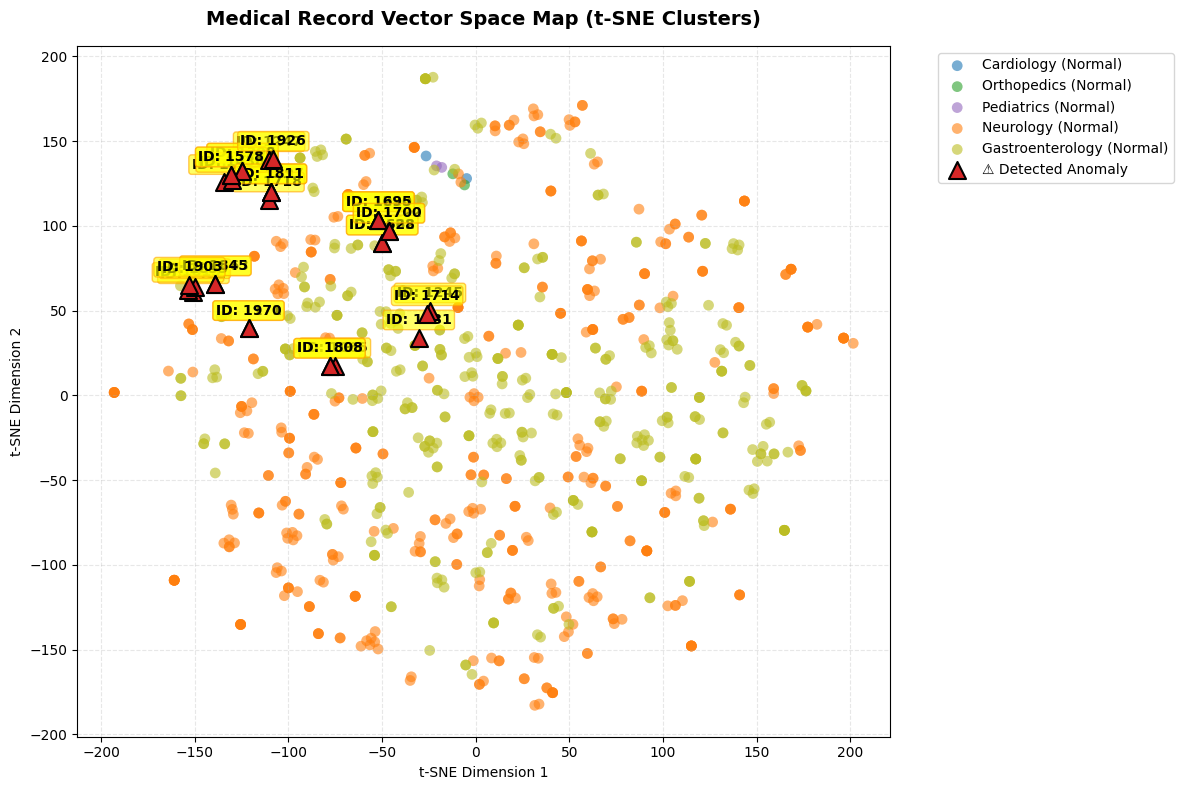

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. Gather all of our vectors and reshape them into a standard 2D matrix
embeddings_matrix = np.array(df['vector'].tolist())

# 2. Configure t-SNE to compress our 768 dimensions into 2 dimensions (X, Y)
# Note: perplexity is set low due to our sample size, adjusting it guides neighborhood density
tsne = TSNE(n_components=2, perplexity=5, random_state=42, n_iter=1000)
embeddings_2d = tsne.fit_transform(embeddings_matrix)

# Map the 2D coordinates back onto our main dataframe for simple plotting
df['tsne_x'] = embeddings_2d[:, 0]
df['tsne_y'] = embeddings_2d[:, 1]

# 3. Setup the visual plot canvas
plt.figure(figsize=(12, 8))
plt.title("Medical Record Vector Space Map (t-SNE Clusters)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("t-SNE Dimension 1", fontsize=10)
plt.ylabel("t-SNE Dimension 2", fontsize=10)

# Define clean colors for our 5 standard specialties
specialty_colors = {
    'Cardiology': '#1f77b4',       # Muted Blue
    'Orthopedics': '#2ca02c',      # Muted Green
    'Pediatrics': '#9467bd',       # Muted Purple
    'Neurology': '#ff7f0e',        # Muted Orange
    'Gastroenterology': '#bcbd22'  # Muted Olive
}

# 4. First, plot the clean ("Normal") records as standard colored circular dots
for spec, color in specialty_colors.items():
    normal_subset = df[(df['specialty'] == spec) & (df['dynamic_anomaly_flag'] == "✅ Normal")]
    plt.scatter(
        normal_subset['tsne_x'],
        normal_subset['tsne_y'],
        label=f"{spec} (Normal)",
        color=color,
        alpha=0.6,
        s=60,
        edgecolors='none'
    )

# 5. Overplot all dynamically flagged anomalies as stark, large red triangles
anomalies_subset = df[df['dynamic_anomaly_flag'] == "⚠️ ANOMALY"]

if len(anomalies_subset) > 0:
    plt.scatter(
        anomalies_subset['tsne_x'],
        anomalies_subset['tsne_y'],
        label="⚠️ Detected Anomaly",
        color='#d62728',  # Crisp Crimson Red
        marker='^',       # Triangle Marker
        s=150,            # Larger size to pop visually
        edgecolors='black',
        linewidths=1.5,
        zorder=5          # Ensures they stay layered on top
    )

    # Label each anomaly triangle with its unique Encounter ID
    for _, row in anomalies_subset.iterrows():
        plt.annotate(
            f"ID: {row['encounter_id']}",
            (row['tsne_x'], row['tsne_y']),
            textcoords="offset points",
            xytext=(0, 10),
            ha='center',
            fontsize=10,
            fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.6, ec="orange")
        )

# Clean up layout, position legend nicely outside data field, and add grid alignment
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()
